# 1. Median Income Map

In [39]:
import pandas as pd

In [40]:
df = pd.read_csv('medianincomedata.csv')
df

,GEO_ID,NAME,S1903_C01_001E,S1903_C01_001M,S1903_C01_002E,S1903_C01_002M,S1903_C01_003E,S1903_C01_003M,S1903_C01_004E,S1903_C01_004M,...,S1903_C03_036E,S1903_C03_036M,S1903_C03_037E,S1903_C03_037M,S1903_C03_038E,S1903_C03_038M,S1903_C03_039E,S1903_C03_039M,S1903_C03_040E,S1903_C03_040M
0,Geography,Geographic Area Name,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,Estimate!!Number!!HOUSEHOLD INCOME BY RACE AND...,Margin of Error!!Number!!HOUSEHOLD INCOME BY R...,...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...,Estimate!!Median income (dollars)!!NONFAMILY H...,Margin of Error!!Median income (dollars)!!NONF...
1,1400000US48113000100,Census Tract 1; Dallas County; Texas,1729,161,1443,156,129,118,0,15,...,62107,25911,104632,15371,54953,38657,54219,21066,-,**
2,1400000US48113000201,Census Tract 2.01; Dallas County; Texas,1213,142,1123,124,46,56,0,15,...,160341,143397,166844,139692,101042,42954,88693,45172,"250,000+",***
3,1400000US48113000202,Census Tract 2.02; Dallas County; Texas,1680,229,1486,236,35,33,21,24,...,91500,10582,163605,34081,74018,19328,74161,11922,-,**
4,1400000US48113000300,Census Tract 3; Dallas County; Texas,2139,311,1692,279,25,43,0,15,...,106184,53736,128529,95809,57375,26098,56786,12093,-,**
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,1400000US48113021100,Census Tract 211; Dallas County; Texas,1763,567,134,136,1016,559,0,15,...,14408,11664,-,**,-,**,-,**,-,**
642,1400000US48113021200,Census Tract 212; Dallas County; Texas,1515,176,401,140,16,26,32,32,...,-,**,-,**,-,**,-,**,-,**
643,1400000US48113980000,Census Tract 9800; Dallas County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**
644,1400000US48113980100,Census Tract 9801; Dallas County; Texas,0,15,0,15,0,15,0,15,...,-,**,-,**,-,**,-,**,-,**


In [41]:
import shapely
import numpy as np
import fiona
#%pip install --upgrade geopandas shapely
#%pip install --upgrade geopandas fiona

In [42]:

import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [43]:

gdf = gpd.read_file("tl_2024_48_tract.shp")

In [44]:
import os
os.listdir()

['ACSST5Y2024.S1903-Data.csv',
 'dallasMedianInc.geojson',
 'dallas_analysis.ipynb',
 'dallas_heat_maps.ipynb',
 'incomeanalysis.ipynb',
 'medianincomedata.csv',
 'mobilityanalysis.ipynb',
 'mobilitydata.csv',
 'snapanalysis.ipynb',
 'SNAPdata.csv',
 'snap_data.csv',
 'tl_2024_48_tract.cpg',
 'tl_2024_48_tract.dbf',
 'tl_2024_48_tract.prj',
 'tl_2024_48_tract.shp',
 'tl_2024_48_tract.shp.ea.iso.xml',
 'tl_2024_48_tract.shp.iso.xml',
 'tl_2024_48_tract.shx',
 'vehicledata.csv']

In [45]:
dallas = gdf[gdf["COUNTYFP"] == "113"]

In [46]:
merged = dallas.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [47]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

In [48]:
merged.to_file('dallasMedianInc.geojson', driver='GeoJSON')

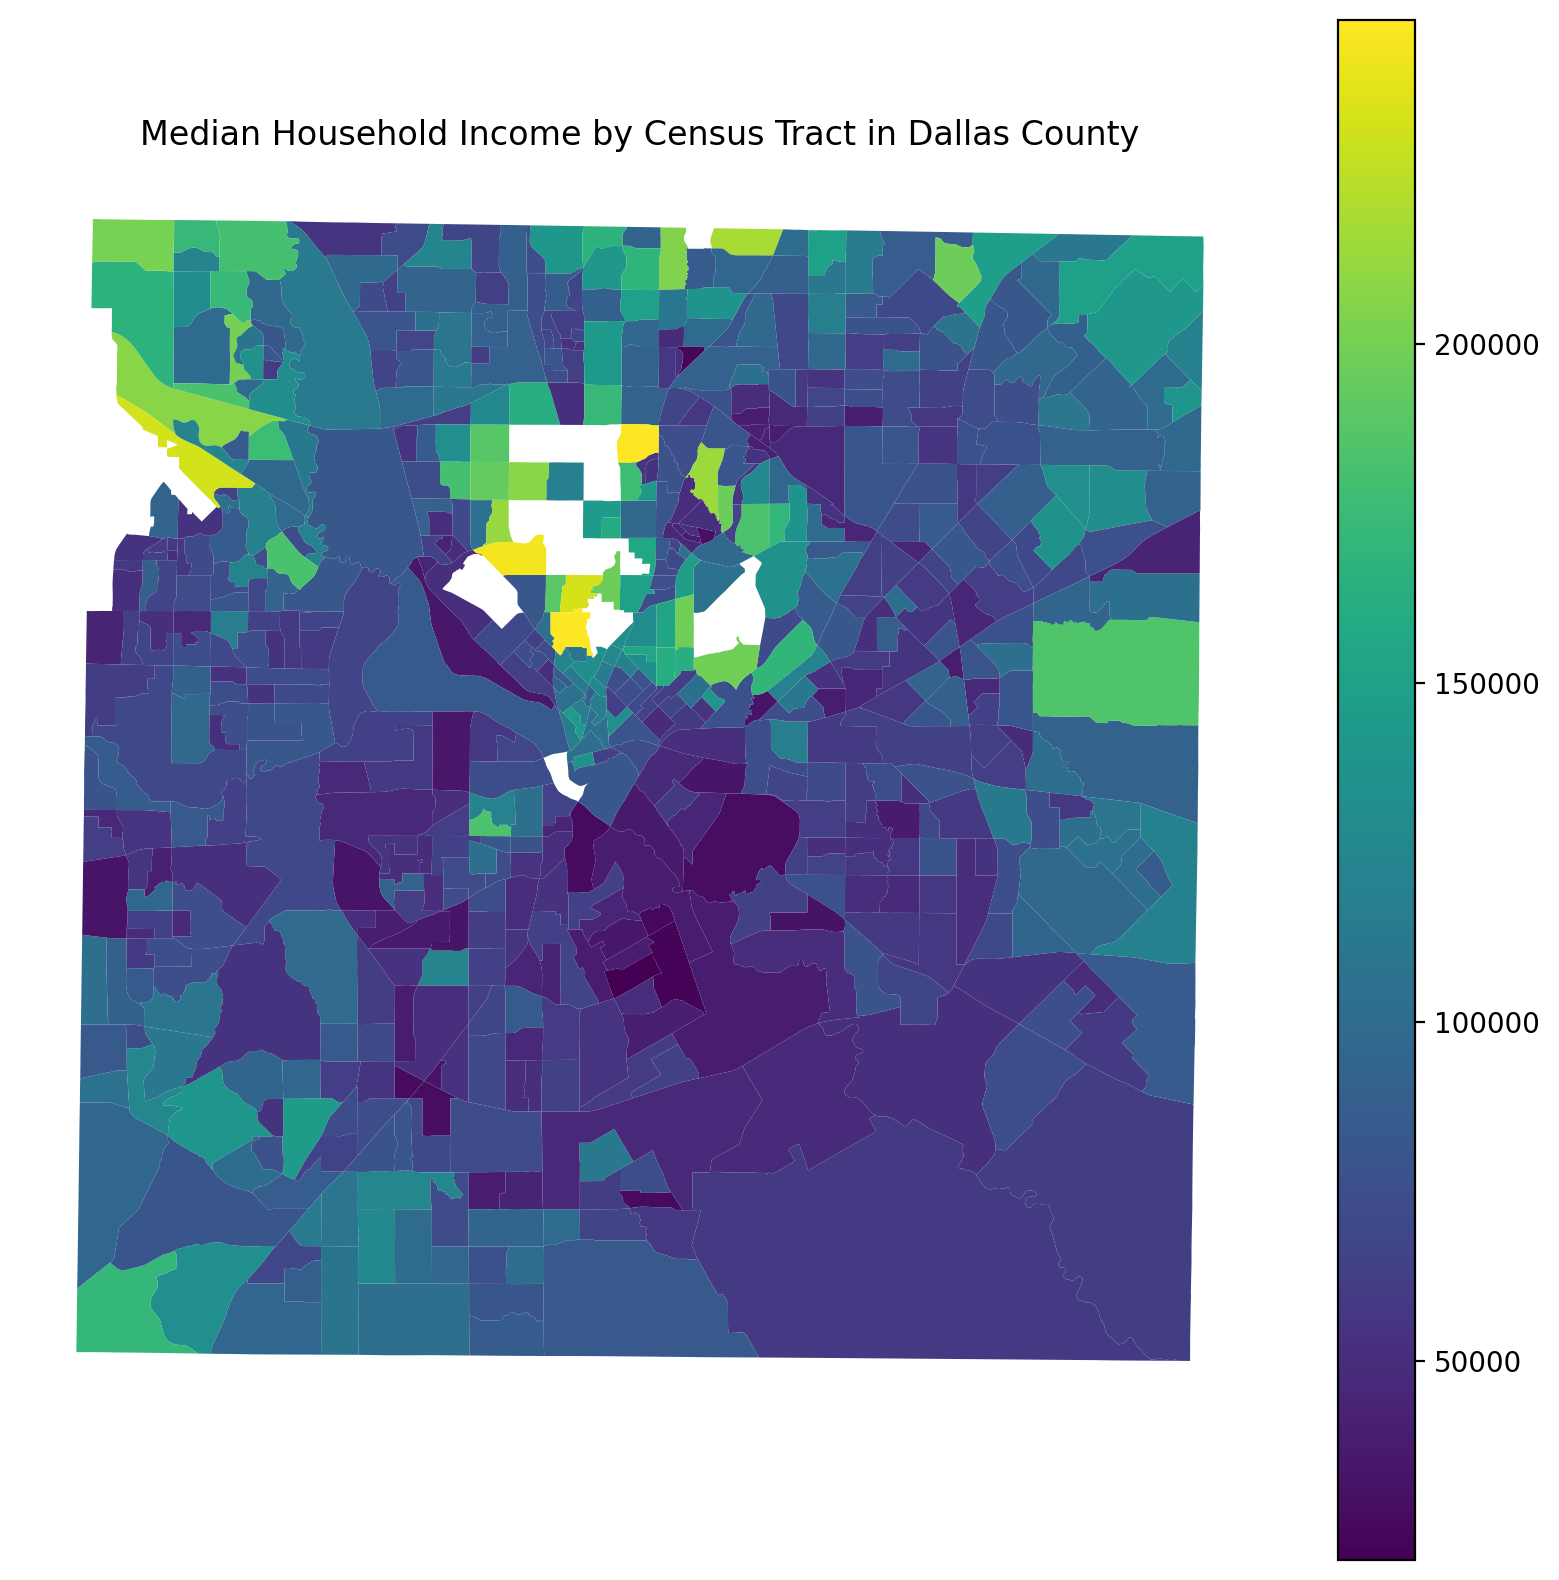

In [49]:
fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="S1903_C03_001E",
    cmap="viridis",
    legend=True,
    ax=ax
)

plt.title("Median Household Income by Census Tract in Dallas County")
plt.axis("off")
plt.show()

# 2. Mobility Map (No Vehicle Access)

In [50]:
df = pd.read_csv('vehicledata.csv')
df

,GEO_ID,NAME,S0802_C01_001E,S0802_C01_001M,S0802_C01_002E,S0802_C01_002M,S0802_C01_003E,S0802_C01_003M,S0802_C01_004E,S0802_C01_004M,...,S0802_C05_097E,S0802_C05_097M,S0802_C05_098E,S0802_C05_098M,S0802_C05_099E,S0802_C05_099M,S0802_C05_100E,S0802_C05_100M,S0802_C05_101E,S0802_C05_101M
0,Geography,Geographic Area Name,Estimate!!Total!!Workers 16 years and over,Margin of Error!!Total!!Workers 16 years and over,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,Estimate!!Total!!Workers 16 years and over!!AG...,Margin of Error!!Total!!Workers 16 years and o...,...,Estimate!!Worked from home!!Workers 16 years a...,Margin of Error!!Worked from home!!Workers 16 ...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...,Estimate!!Worked from home!!PERCENT ALLOCATED!...,Margin of Error!!Worked from home!!PERCENT ALL...
1,1400000US48113000100,Census Tract 1; Dallas County; Texas,2344,324,2.9,3.5,5.2,3.4,35.7,8.8,...,25,16.8,(X),(X),(X),(X),(X),(X),(X),(X)
2,1400000US48113000201,Census Tract 2.01; Dallas County; Texas,1680,213,0,2.9,6.8,6.5,51.3,6,...,19.3,15.1,(X),(X),(X),(X),(X),(X),(X),(X)
3,1400000US48113000202,Census Tract 2.02; Dallas County; Texas,2419,388,0,2,16,9.2,56.6,8.5,...,2.6,3.4,(X),(X),(X),(X),(X),(X),(X),(X)
4,1400000US48113000300,Census Tract 3; Dallas County; Texas,2623,425,0,1.9,2.1,2,77.3,6,...,6.2,6.3,(X),(X),(X),(X),(X),(X),(X),(X)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,1400000US48113021100,Census Tract 211; Dallas County; Texas,1793,548,11.5,9.1,3.5,2.3,31.2,12.1,...,0,31,(X),(X),(X),(X),(X),(X),(X),(X)
642,1400000US48113021200,Census Tract 212; Dallas County; Texas,2592,703,2.2,1.9,15.8,7.6,38.7,10.9,...,100,100,(X),(X),(X),(X),(X),(X),(X),(X)
643,1400000US48113980000,Census Tract 9800; Dallas County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)
644,1400000US48113980100,Census Tract 9801; Dallas County; Texas,0,15,-,**,-,**,-,**,...,-,**,(X),(X),(X),(X),(X),(X),(X),(X)


In [51]:
import shapely
import numpy as np
import fiona
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib inline
%config InlineBackend.figure_format = "retina"

gdf = gpd.read_file("tl_2024_48_tract.shp")

In [52]:
dallas = gdf[gdf["COUNTYFP"] == "113"]

In [53]:
merged_2 = dallas.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [54]:
merged_2["S0802_C01_094E"] = pd.to_numeric(
    merged_2["S0802_C01_094E"],
    errors="coerce"
)

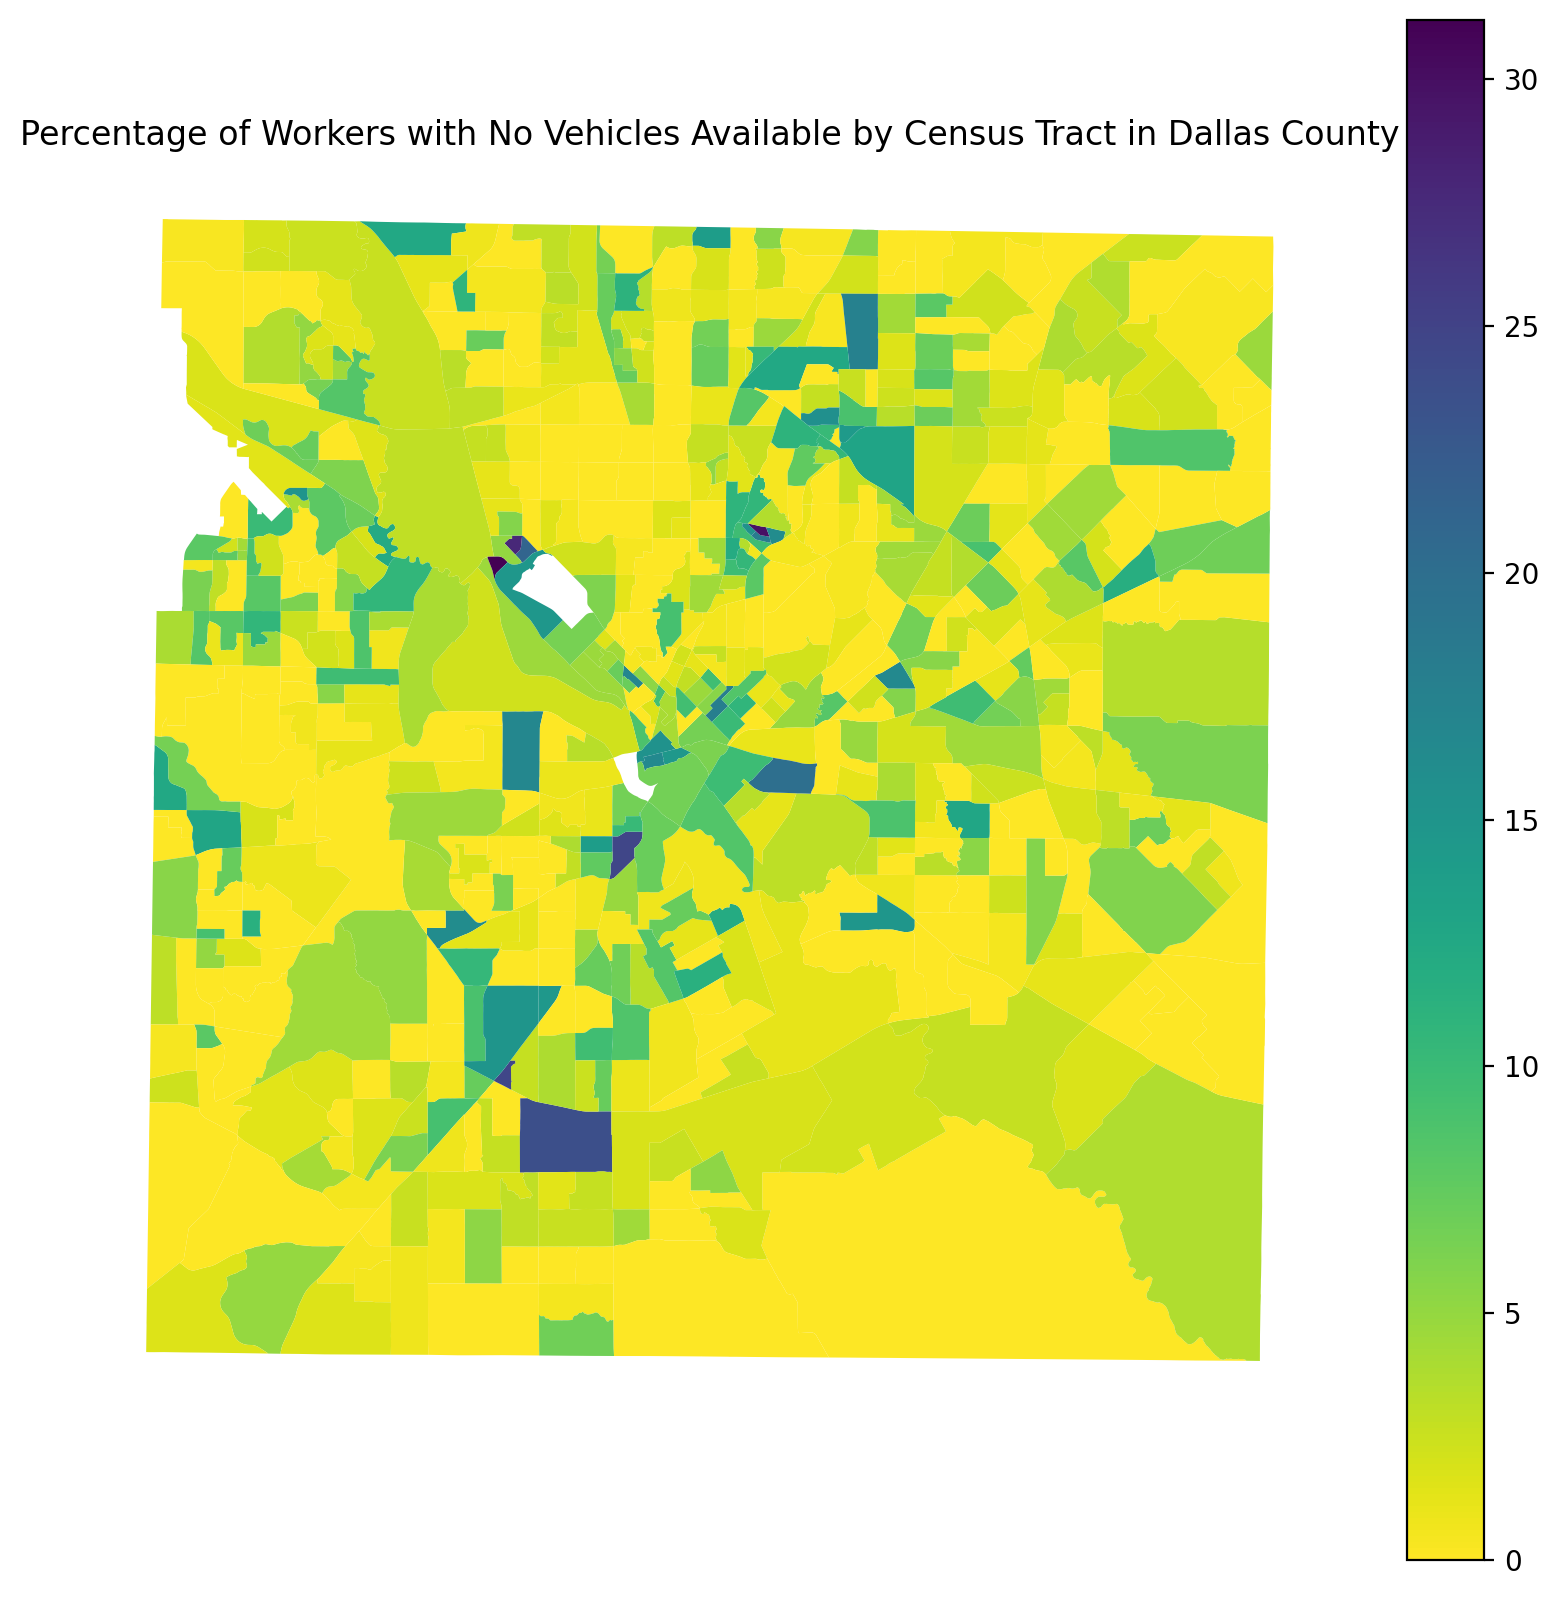

In [55]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_2.plot(
    column="S0802_C01_094E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of Workers with No Vehicles Available by Census Tract in Dallas County")
plt.axis("off")
plt.show()

# 3. SNAP Map

In [56]:
df = pd.read_csv('snap_data.csv')
df

,GEO_ID,NAME,S2201_C01_001E,S2201_C01_001M,S2201_C01_002E,S2201_C01_002M,S2201_C01_003E,S2201_C01_003M,S2201_C01_004E,S2201_C01_004M,...,S2201_C06_034E,S2201_C06_034M,S2201_C06_035E,S2201_C06_035M,S2201_C06_036E,S2201_C06_036M,S2201_C06_037E,S2201_C06_037M,S2201_C06_038E,S2201_C06_038M
0,Geography,Geographic Area Name,Estimate!!Total!!Households,Margin of Error!!Total!!Households,Estimate!!Total!!Households!!With one or more ...,Margin of Error!!Total!!Households!!With one o...,Estimate!!Total!!Households!!No people in the ...,Margin of Error!!Total!!Households!!No people ...,Estimate!!Total!!Households!!Married-couple fa...,Margin of Error!!Total!!Households!!Married-co...,...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...,Estimate!!Percent households not receiving foo...,Margin of Error!!Percent households not receiv...
1,1400000US48113000100,Census Tract 1; Dallas County; Texas,1729,161,526,105,1203,164,962,140,...,(X),(X),(X),(X),7.9,5.7,26,10.9,66.1,12.5
2,1400000US48113000201,Census Tract 2.01; Dallas County; Texas,1213,142,352,89,861,120,719,88,...,(X),(X),(X),(X),8,5.7,23.1,9.7,69,10.7
3,1400000US48113000202,Census Tract 2.02; Dallas County; Texas,1680,229,381,142,1299,206,825,186,...,(X),(X),(X),(X),14,12.6,24.1,8.8,61.9,12.5
4,1400000US48113000300,Census Tract 3; Dallas County; Texas,2139,311,542,120,1597,308,1054,301,...,(X),(X),(X),(X),8.2,6.2,21.3,14.7,70.5,14.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
641,1400000US48113021100,Census Tract 211; Dallas County; Texas,1763,567,1084,578,679,201,411,214,...,(X),(X),(X),(X),5.3,7.7,51.6,20.4,43.2,21.8
642,1400000US48113021200,Census Tract 212; Dallas County; Texas,1515,176,563,152,952,190,828,260,...,(X),(X),(X),(X),8.4,5.7,29.4,11.8,62.2,13.1
643,1400000US48113980000,Census Tract 9800; Dallas County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**
644,1400000US48113980100,Census Tract 9801; Dallas County; Texas,0,15,0,15,0,15,0,15,...,(X),(X),(X),(X),-,**,-,**,-,**


In [57]:
merged_3 = dallas.merge(
    df,
    left_on="GEOIDFQ",
    right_on="GEO_ID",
    how="left"
)

In [58]:
merged_3["S2201_C04_001E"] = pd.to_numeric(
    merged_3["S2201_C04_001E"],
    errors="coerce"
)

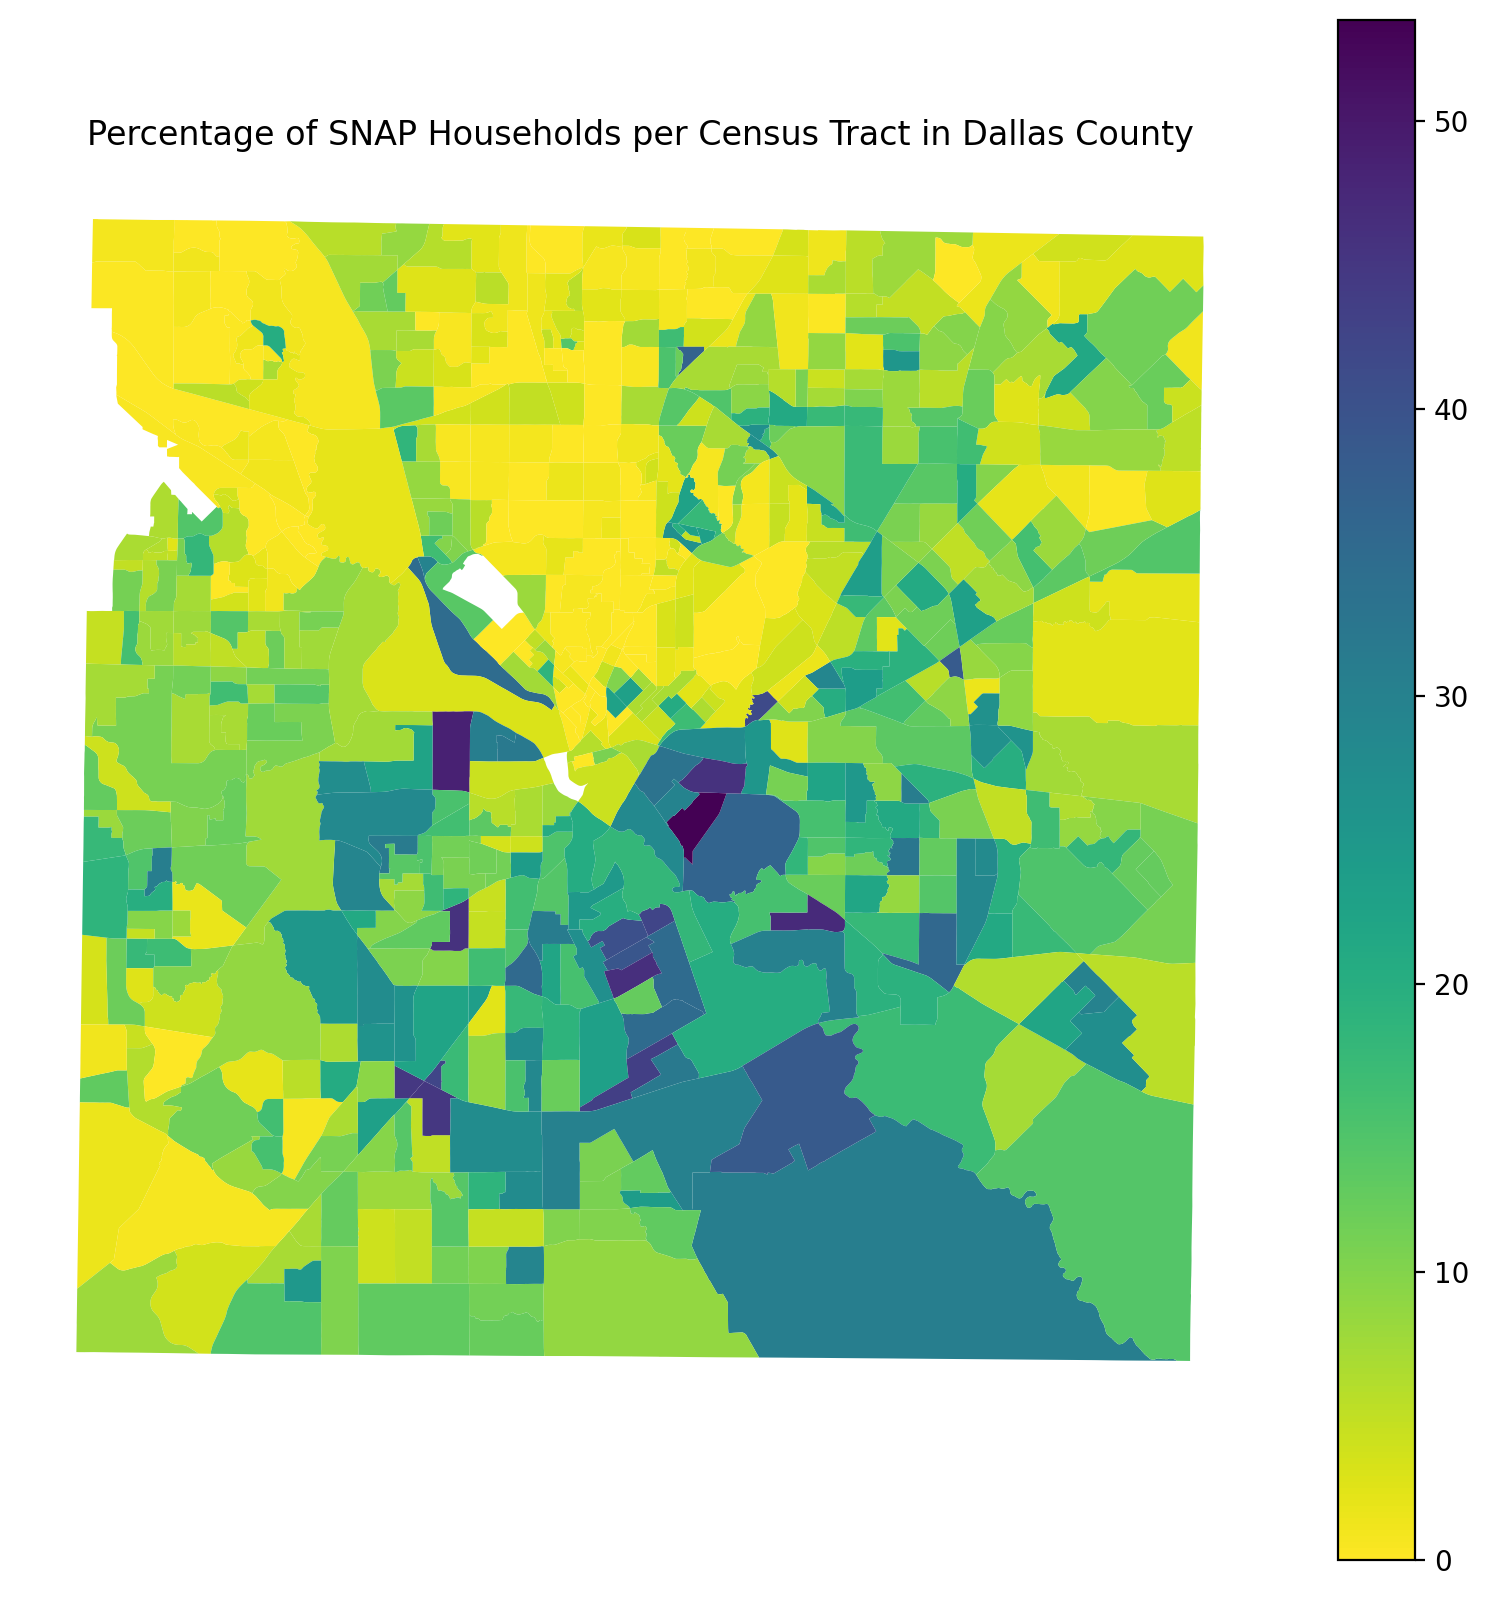

In [59]:
fig, ax = plt.subplots(figsize=(10, 10))

merged_3.plot(
    column="S2201_C04_001E",
    cmap="viridis_r",
    legend=True,
    ax=ax
)

plt.title("Percentage of SNAP Households per Census Tract in Dallas County")
plt.axis("off")
plt.show()

# 4. Low Income Binary Map

This map displays if each census tract has a median income less than 80% of the statewide median income. The 2024 statewide Texas Median Income Per Household was $79,721. A "household" is defined as all people who occupy a single housing unit, regardless of their relationship.

In [60]:
merged["binary_income"] = (
    merged["S1903_C03_001E"] < 0.8*79721
).astype(int)
#1 if median income less than 0.8*79721
#0 if median income greater than or equal to 0.8*79721

In [61]:
merged["binary_income"]

0      0
1      0
2      1
3      0
4      0
      ..
640    1
641    0
642    0
643    0
644    0
Name: binary_income, Length: 645, dtype: int32

In [62]:
merged["S1903_C03_001E"] = pd.to_numeric(
    merged["S1903_C03_001E"],
    errors="coerce"
)

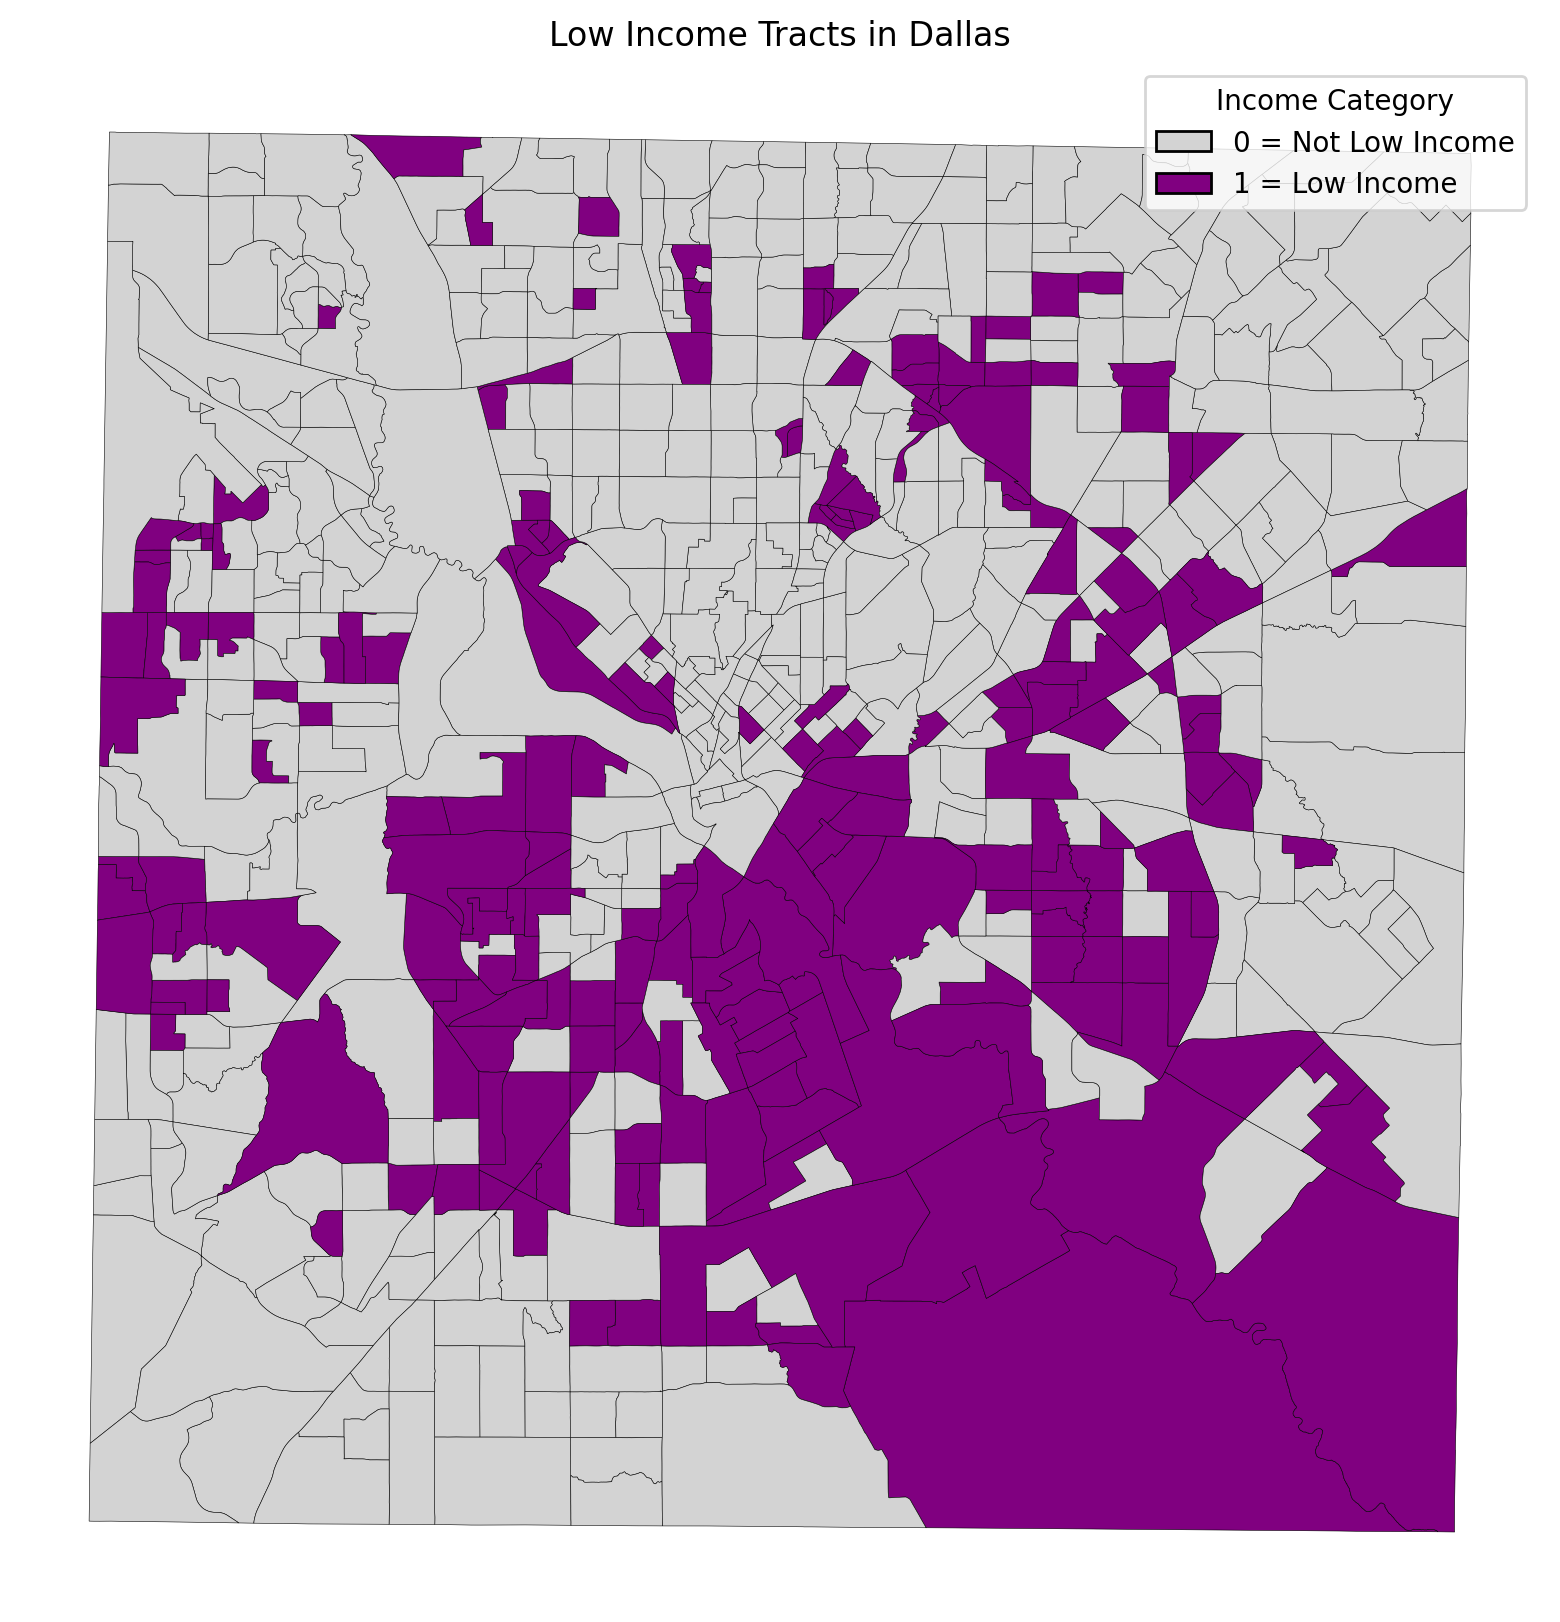

In [63]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cmap = ListedColormap(["lightgrey", "purple"])

fig, ax = plt.subplots(figsize=(10, 10))

merged.plot(
    column="binary_income",
    cmap=cmap,
    categorical=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax
)

legend_elements = [
    Patch(facecolor="lightgrey", edgecolor="black", label="0 = Not Low Income"),
    Patch(facecolor="purple", edgecolor="black", label="1 = Low Income")
]

ax.legend(handles=legend_elements, title="Income Category")

plt.title("Low Income Tracts in Dallas")
plt.axis("off")
plt.show()

# 5. Metropolitan Area Median Family Income

This map displays if each census tract has a median income less than 80% of the metropolitan area's median income. The median income for the Dallas Metropolitan Area for 2024